In [1]:
import os, re
import numpy as np

# plotting styles
import matplotlib as mpl
from matplotlib import pyplot as plt
# include .. in the path
import sys
import os

sys.path.insert(0, "..")


%matplotlib inline

mpl.rcParams['figure.dpi']= 150

In [2]:
from astropy.table import Table

In [16]:
# dlacat = Table.read("../../desi-mock-gpdla-20250224-y3-learned-epoch320/dlacat-v5.9.5-mockcat.fits")
dlacat = Table.read("../../desi-mock-saclay-gpdla-y3-learned-epoch561-20250302/dlacat-v5.9.5-mockcat.fits")

In [18]:
# all spectra with pdla > 0.5
ind = (dlacat["P_DLA"] > 0.5)
# targetid
all_targetids = np.unique(dlacat["TARGETID"][ind])
all_targetids.shape

(96041,)

In [19]:
dlacat[(dlacat["Z_DLA"] > 4.75) & (dlacat["Z_DLA"] < 5.25) & (dlacat["NHI"] > 20.3) & (dlacat["SNR_REDSIDE"] > 6) & (dlacat["P_DLA"] > 0.99)]

TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE,DLAID,Z_DLA,Z_DLA_ERR,NHI,NHI_ERR,DLAFLAG,P_DLA,P_NULL,LOGP_DLA,LOGP_NULL,MODEL_P
int64,float64,float64,float64,float64,float64,bytes13,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64


## Testing

In [5]:
import desispec.io
from desispec.interpolation import resample_flux
from desispec.coaddition import coadd_cameras, resample_spectra_lin_or_log
from desiutil.log import log
import constants


## Problematic runs

In [6]:
# load QSO catalog
import desispec.io
from desispec.interpolation import resample_flux
from desispec.coaddition import coadd_cameras, resample_spectra_lin_or_log
from desiutil.log import log
import constants

from desiutil.log import log
from astropy.table import Table, vstack
import numpy as np
from scipy.interpolate import interp1d
import fitsio
import constants
import desispec.io

def read_catalog(qsocat, balmask, bytile):
    """
    read quasar catalog

    Arguments
    ---------
    qsocat (str) : path to quasar catalog
    balmask (bool) : should BAL attributes from baltools be read in?
    bytile (bool) : catalog is tilebased, default assumption is healpix

    Returns
    -------
    table of relevant attributes for quasars defined in constants.py

    """
    if constants.no_bal:
        balmask = True

    if balmask:
        try:
            # read the following columns from qsocat
            cols = [
                "TARGETID",
                "TARGET_RA",
                "TARGET_DEC",
                "Z",
                "HPXPIXEL",
                "AI_CIV",
                "NCIV_450",
                "VMIN_CIV_450",
                "VMAX_CIV_450",
                "SPECTYPE",
                "ZWARN",
            ]
            if bytile:
                cols = [
                    "TARGETID",
                    "TARGET_RA",
                    "TARGET_DEC",
                    "Z",
                    "TILEID",
                    "PETAL_LOC",
                    "AI_CIV",
                    "NCIV_450",
                    "VMIN_CIV_450",
                    "VMAX_CIV_450",
                    "SPECTYPE",
                    "ZWARN",
                ]
            catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))
        except:
            log.error(f"cannot find {cols} in quasar catalog")
            exit(1)
    else:
        # read the following columns from qsocat
        cols = [
            "TARGETID",
            "TARGET_RA",
            "TARGET_DEC",
            "Z",
            "HPXPIXEL",
            "SPECTYPE",
            "ZWARN",
        ]
        if bytile:
            cols = [
                "TARGETID",
                "TARGET_RA",
                "TARGET_DEC",
                "Z",
                "TILEID",
                "PETAL_LOC",
                "SPECTYPE",
                "ZWARN",
            ]
        catalog = Table(fitsio.read(qsocat, ext=1, columns=cols))

    log.info(f"Successfully read quasar catalog: {qsocat}")

    # Apply redshift cuts
    zmask = (catalog["Z"] > constants.zmin_qso) & (catalog["Z"] < constants.zmax_qso)
    log.info(f"objects in catalog: {len(catalog)} ")
    log.info(
        f"restricting to {constants.zmin_qso} < z < {constants.zmax_qso}: {np.sum(zmask)} objects remain"
    )

    # Apply bal mask
    if constants.no_bal:
        balind = catalog["NCIV_450"] > 0
        zmask = zmask & ~balind
        log.info(f"objects in catalog without BAL: {np.sum(zmask)}")

    # Apply zwarning mask
    if constants.zwarning:
        zmask = zmask & (catalog["ZWARN"] == 0)
        log.info(f"objects in catalog without ZWARN: {np.sum(zmask)}")

    # Apply spectype mask
    if constants.is_qso:
        zmask = zmask & (catalog["SPECTYPE"] == "QSO")
        log.info(f"objects in catalog with SPECTYPE QSO: {np.sum(zmask)}")

    catalog = catalog[zmask]

    return catalog


In [7]:
qsocat = "/global/cfs/cdirs/desi/users/martini/bal-catalogs/kibo/QSO_cat_kibo_main_dark_healpix_v3-altbal.fits"
balmask = True
tilebased = False
release = "kibo"
program = "dark"
survey = "main"


catalog = read_catalog(qsocat, balmask, tilebased)
catalog

INFO:3928237521.py:93:read_catalog: Successfully read quasar catalog: /global/cfs/cdirs/desi/users/martini/bal-catalogs/kibo/QSO_cat_kibo_main_dark_healpix_v3-altbal.fits
INFO:3928237521.py:97:read_catalog: objects in catalog: 2776508 
INFO:3928237521.py:98:read_catalog: restricting to 2.0 < z < 7.0: 945939 objects remain


TARGETID,Z,ZWARN,SPECTYPE,TARGET_RA,TARGET_DEC,HPXPIXEL,AI_CIV,NCIV_450,VMIN_CIV_450,VMAX_CIV_450
int64,float64,int64,str6,float64,float64,int64,float32,int32,float32[17],float32[17]
39627322701125813,2.414734397670648,0,QSO,21.876410751633088,-19.44134382450835,16725,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627322701128888,3.0154471067575725,0,QSO,21.970054362083097,-19.41049376322168,16725,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627323124748972,2.4517887261865723,0,QSO,48.59381358198363,-19.38441935595103,36262,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627328396987837,2.8533521490590696,0,QSO,21.24727841246936,-19.20124094691398,16727,951.46173,1,886.1091 .. -1.0,2935.3394 .. -1.0
39627328396987898,2.561227529673689,0,QSO,21.249249187620947,-19.26203373336111,16727,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627328396988601,2.3311749519806138,0,QSO,21.269584107438064,-19.19107879305247,16727,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627328396988627,2.9022172102772603,0,QSO,21.27035252800352,-19.236341906004586,16727,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627328396990519,2.778629985909482,0,GALAXY,21.32234557948003,-19.302103238364907,16725,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0
39627328396991055,2.0210797345590192,0,QSO,21.338167988817418,-19.34281394319632,16725,371.5753,1,900.2499 .. -1.0,1925.2574 .. -1.0


In [93]:
# overlapping DLA 39627604172474708

tid =  39627971190851107 #39627604172474708 #3962766490 5998858#39627888101695377 #39628167320702247 #39628293179180549###	#39628126472374263 #39627912197964139 #39627888101695377
idx = np.where(catalog["TARGETID"] == tid)[0][0]
catalog[idx]

TARGETID,Z,ZWARN,SPECTYPE,TARGET_RA,TARGET_DEC,HPXPIXEL,AI_CIV,NCIV_450,VMIN_CIV_450,VMAX_CIV_450
int64,float64,int64,str6,float64,float64,int64,float32,int32,float32[17],float32[17]
39627971190851107,3.3088253236949923,0,QSO,338.4316722659075,7.468219391702266,19254,0.0,0,-1.0 .. -1.0,-1.0 .. -1.0


In [94]:
# read spectra from healpix
hpx = catalog[idx]["HPXPIXEL"]
healpix = hpx

datapath = f"/global/cfs/cdirs/desi/spectro/redux/{release}/healpix/{survey}/{program}"

coaddname = f"coadd-{survey}-{program}-{str(healpix)}.fits"
coadd = os.path.join(datapath, str(healpix // 100), str(healpix), coaddname)

hpxcatalog = catalog[catalog["HPXPIXEL"] == hpx]

specobj = desispec.io.read_spectra(
    coadd,
    targetids=hpxcatalog["TARGETID"],
    skip_hdus=["EXP_FIBERMAP", "SCORES", "EXTRA_CATALOG"],
)


INFO:spectra.py:391:read_spectra: iotime 1.645 sec to read coadd-main-dark-19254.fits at 2025-03-25T21:44:33.717766


In [95]:
specobj = coadd_cameras(specobj)

In [96]:
from collections import namedtuple

z_qso = catalog[idx]["Z"]

this_cat = catalog["TARGETID"][catalog["HPXPIXEL"] == hpx]
this_idx = np.where(this_cat == tid)[0][0]

# this_idx = 37

# Define a namedtuple for storing each spectrum's data
SpectrumData = namedtuple(
    "SpectrumData", ["wavelengths", "flux", "noise_variance", "pixel_mask"]
)

ivar = specobj.ivar["brz"][this_idx]
noise_variance = np.zeros(ivar.shape)
ind = ivar == 0
noise_variance[:] = np.nan
noise_variance[~ind] = 1 / ivar[~ind]

pixel_mask = specobj.mask["brz"][this_idx].astype(np.bool_)
pixel_mask[ind] = True

spectrum_data = SpectrumData(
    wavelengths = specobj.wave["brz"],
    flux = specobj.flux["brz"][this_idx],
    noise_variance = noise_variance,
    pixel_mask = pixel_mask
)


## DESI Spectra on the GP-DLA Finder

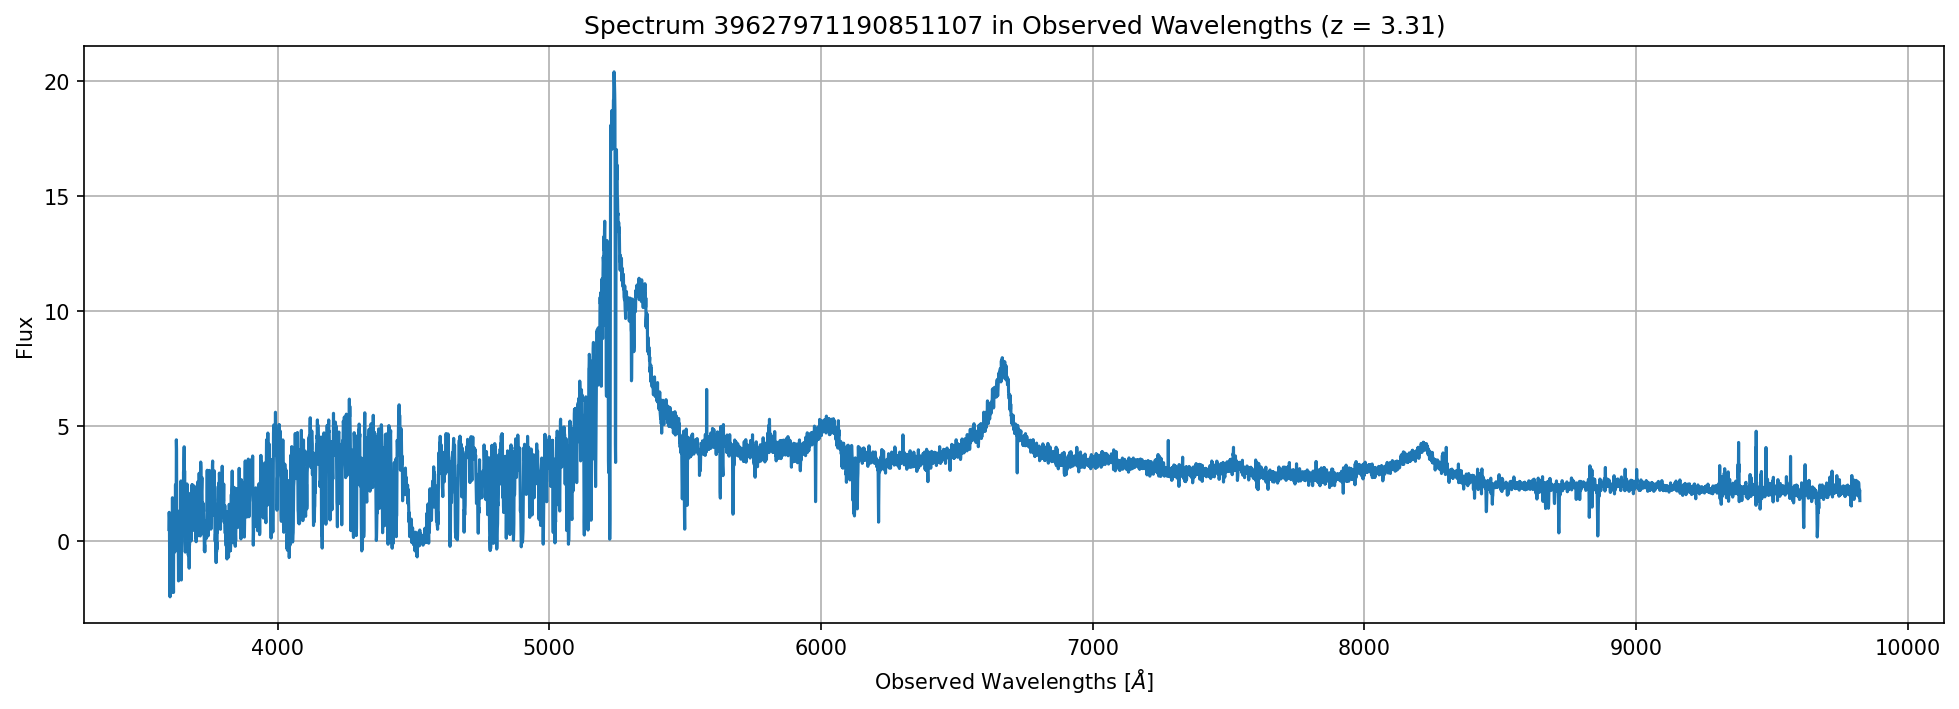

In [97]:
# Find the first high SNR and z > 3.2 spectrum
# spectrum_id, spectrum_data, z_qso = find_high_snr_z_spectrum(reader, snr_threshold=5, redshift_threshold=3.4)


# Access wavelengths, flux, and noise variance from the DESI reader
wavelengths = spectrum_data.wavelengths
flux = spectrum_data.flux
noise_variance = spectrum_data.noise_variance
pixel_mask = spectrum_data.pixel_mask

rest_wavelengths = wavelengths / (1 + z_qso)

# Plot the spectrum in "observed wavelengths"
plt.figure(figsize=(16, 5))
plt.plot(wavelengths, flux)
plt.xlabel("Observed Wavelengths [$\AA$]")
plt.ylabel("Flux")
plt.title(f"Spectrum {tid} in Observed Wavelengths (z = {z_qso:.2f})")
plt.grid(True)
plt.show()

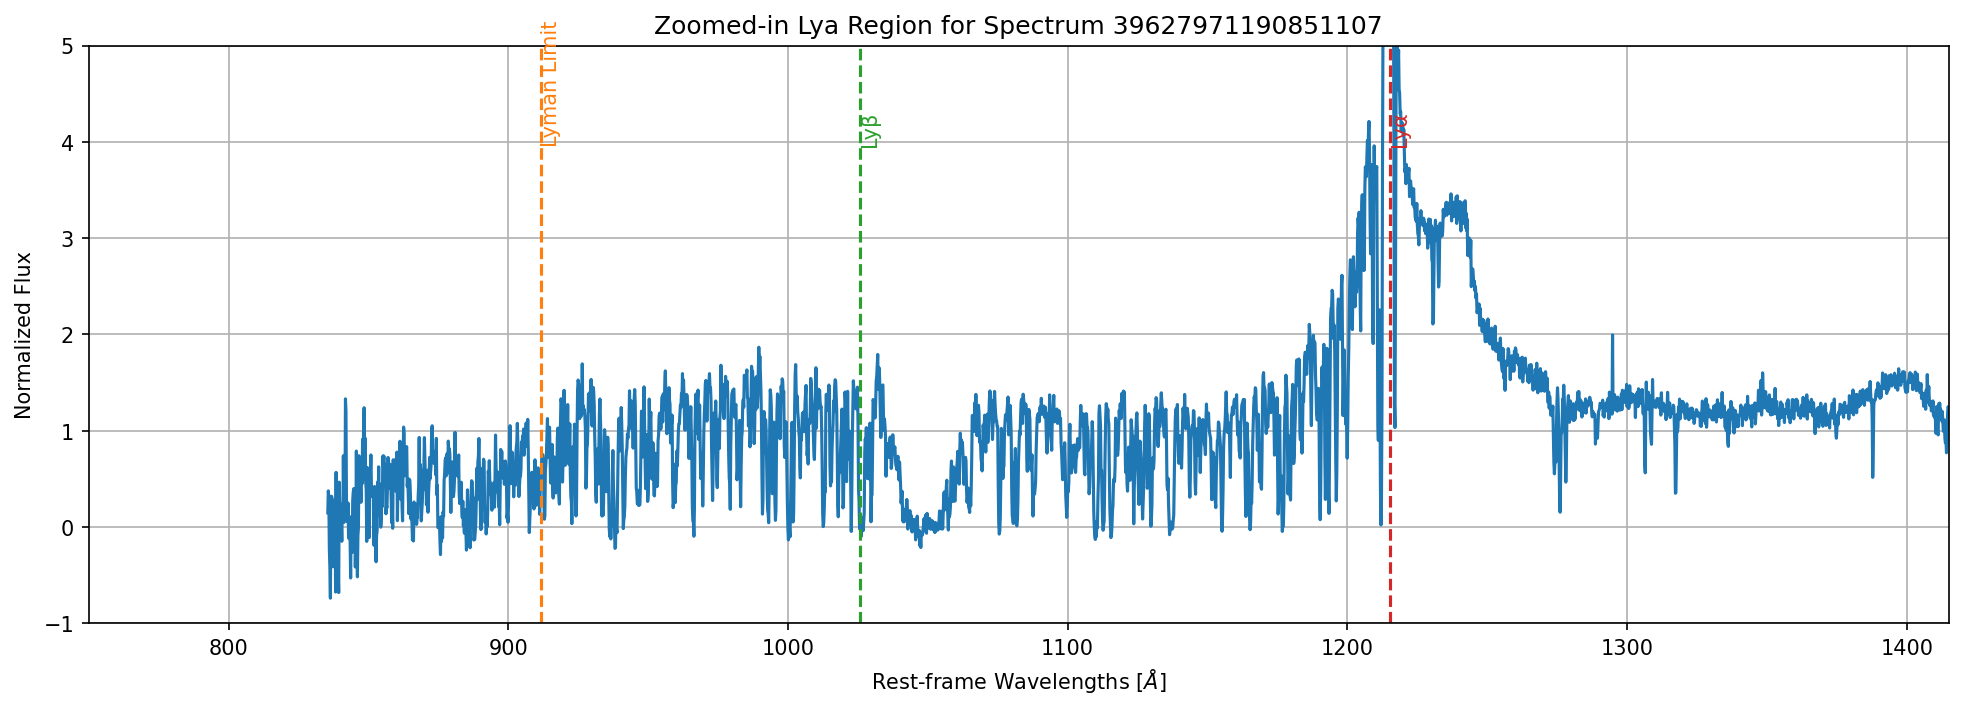

In [98]:
# Emission lines for Lyα, Lyβ, and Lyman Limit
lya_wavelength = 1215.24
lyb_wavelength = 1025.72
ly_limit_wavelength = 911.76

# Zoom in on the Lyα region (wavelengths 900 Å to 1216 Å)
plt.figure(figsize=(16, 5))
plt.plot(rest_wavelengths, flux / np.mean(flux))
plt.xlabel("Rest-frame Wavelengths [$\AA$]")
plt.ylabel("Normalized Flux")
plt.ylim(-1, 5)
plt.xlim(750, 1415)
plt.title(f"Zoomed-in Lya Region for Spectrum {tid}")
plt.grid(True)

# Highlight the Lyα, Lyβ, and Lyman Limit emission lines
plt.vlines(lya_wavelength, -1, 5, color="C3", ls="--")
plt.text(lya_wavelength, 4, r"Lyα", rotation="vertical", color="C3")

plt.vlines(lyb_wavelength, -1, 5, color="C2", ls="--")
plt.text(lyb_wavelength, 4, r"Lyβ", rotation="vertical", color="C2")

plt.vlines(ly_limit_wavelength, -1, 5, color="C1", ls="--")
plt.text(ly_limit_wavelength, 4, r"Lyman Limit", rotation="vertical", color="C1")

# Show the plot
plt.show()

# Tutorial: Automating DLA Detection with Gaussian Processes in DESI

author: Ming-Feng Ho (jibancat)


In this tutorial, we'll show you how to automate the detection of  DLA (log NHI = 20.3 - 23) in quasar spectra using Gaussian processes. I will make the tutorial flexible to adapt to any trained GP model and any prior can be used.

## Understand how to use Bayesian model selection

Bayesian model selection provides a way to compare the performance of different models in a Bayesian way.
For a good lecture, mathmaticalmonk provides a nice [video](https://youtu.be/1CFof6hU3cI).
In a nutshell, you can think Bayesian model selection as a Bayesian way to do hypothesis testing.

Suppose you have two hypothesis: $M_1$ and $M_2$.
Each model has some capability to explain the data, $\mathcal{D}$.
The probability that $M_1$ can explain the data is $p(\mathcal{D} \mid M_1)$, and vice versa.
This probability, the ability of hypothesis explaining a given data, is also called "likelihood".

However, likelihoods are not the whole story.
We need to consider the fact that the $M_1$ and $M_2$ have different occurrence rates, i.e., one of the hypothesis might be rarer happened than the other one.
For example, the number of people who have cancers is less than people who don't, so the hypothsis of a person having a cancer should be assigned a smaller probability.
When you don't consider the base rate, you might misinterpret the results.
This is often called the [base-rate fallacy](https://en.wikipedia.org/wiki/Base_rate).




In some scientific domains, people claim that a p-value smaller than 0.05 is required to reject the null hypothesis. However, as a Bayesian, we prefer to express the problem in a Bayesian way, which takes into account the effects of the base-rate fallacy.

In Bayesian statistics, we can incorporate the prior probabilities, which are the probabilities of the hypotheses, $p(M)$. The prior probability is essentially the occurrence of the hypothesis or how common it is. With prior probabilities, we can calculate the posterior probability of the hypothesis, which is how likely it is that the hypothesis is true. For example, if $M_1$ is the null hypothesis with a prior probability of $p(M_1) = 0.95$, this means that it occurs more often than the other hypothesis.

The likelihood of $M_2$ needs to be $p(\mathcal{D} \mid M_2) > 0.95$ to make the hypothesis $M_2$ more likely than $M_1$. To calculate the posterior probability of $M_2$, we can use the formula:
$$
p(M_1 \mid \mathcal{D}) = \frac{p(M_1) p(\mathcal{D} \mid M_1)}{ p(M_1) p(\mathcal{D} \mid M_1) + p(M_2) p(\mathcal{D} \mid M_2) }
$$
Note that $p(M_2) = 1 - p(M_1) = 0.05$.

This means that the likelihood of $M_1$ is less than 0.05, which is almost equivalent to saying that the p-value (likelihood in the Bayesian sense) is less than 0.05.

In the following tutorial, we will use Bayesian model selection to find spectra with Lyman alpha absorbers. It is important to note that in Bayesian statistics, models and hypotheses are interchangeable.



## Visualizations

## Inference with the DESI Y3 model

## A wrap

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from run_bayes_select import process_single_spectrum
from gpy_dla_detection.set_parameters import Parameters
from gpy_dla_detection.model_priors import PriorCatalog
from gpy_dla_detection.dla_samples import DLASamplesMAT
from gpy_dla_detection.subdla_samples import SubDLASamplesMAT
from gpy_dla_detection.bayesian_model_selection import BayesModelSelect
from gpy_dla_detection.null_gp import NullGPMAT
from gpy_dla_detection.dla_gp import DLAGPMAT
from gpy_dla_detection.subdla_gp import SubDLAGPMAT
from gpy_dla_detection.process_helpers import initialize_results

class SpectrumProcessor:
    def __init__(self, spectra_filename, zbest_filename, learned_file, catalog_name,
                 los_catalog, dla_catalog, dla_samples_file, sub_dla_samples_file,
                 max_dlas=3, min_z_separation=3000.0, prev_tau_0=0.00554, prev_beta=3.182, k=20, dlambda=0.25,
                min_lambda=912.75,
                max_lambda=1216.75,):
        
        self.spectra_filename = spectra_filename
        self.zbest_filename = zbest_filename
        self.learned_file = learned_file
        self.catalog_name = catalog_name
        self.los_catalog = los_catalog
        self.dla_catalog = dla_catalog
        self.dla_samples_file = dla_samples_file
        self.sub_dla_samples_file = sub_dla_samples_file
        self.max_dlas = max_dlas
        self.min_z_separation = min_z_separation
        self.prev_tau_0 = prev_tau_0
        self.prev_beta = prev_beta
        
        # Initialize parameters
        self.params = Parameters(
            loading_min_lambda=910,
            loading_max_lambda=1550,
            normalization_min_lambda=1425,
            normalization_max_lambda=1475,
            min_lambda=min_lambda,
            max_lambda=max_lambda,
            dlambda=dlambda,
            k=k,
            max_noise_variance=3 ** 2,
        )
        
        # Initialize priors and sample catalogs
        self.prior = PriorCatalog(self.params, self.catalog_name, self.los_catalog, self.dla_catalog)
        self.dla_samples = DLASamplesMAT(self.params, self.prior, self.dla_samples_file)
        self.subdla_samples = SubDLASamplesMAT(self.params, self.prior, self.sub_dla_samples_file)
        
        # Bayesian model selection
        self.bayes = BayesModelSelect([0, 1, self.max_dlas], 2)
        
        # Instantiate models
        self.null_gp = NullGPMAT(self.params, self.prior, self.learned_file, prev_tau_0=self.prev_tau_0, prev_beta=self.prev_beta)
        self.dla_gp = DLAGPMAT(
            params=self.params, prior=self.prior, dla_samples=self.dla_samples, min_z_separation=self.min_z_separation,
            learned_file=self.learned_file, broadening=True, prev_tau_0=self.prev_tau_0, prev_beta=self.prev_beta
        )
        self.subdla_gp = SubDLAGPMAT(
            params=self.params, prior=self.prior, dla_samples=self.subdla_samples, min_z_separation=self.min_z_separation,
            learned_file=self.learned_file, broadening=True, prev_tau_0=self.prev_tau_0, prev_beta=self.prev_beta
        )
        
        # Initialize results dictionary
        num_spectra = 1
        num_dla_samples = self.dla_samples.log_nhi_samples.shape[0]
        self.results = initialize_results(num_spectra, self.max_dlas, num_dla_samples=num_dla_samples)

    def process_spectrum(self, idx, target_id, z_qso, wavelengths, rest_wavelengths, flux, noise_variance, pixel_mask):
        process_single_spectrum(
            idx=idx,
            target_id=target_id,
            z_qso=z_qso,
            wavelengths=wavelengths,
            rest_wavelengths=rest_wavelengths,
            flux=flux,
            noise_variance=noise_variance,
            pixel_mask=pixel_mask,
            params=self.params,
            prior=self.prior,
            dla_samples=self.dla_samples,
            subdla_samples=self.subdla_samples,
            bayes=self.bayes,
            results=self.results,
            max_dlas=self.max_dlas,
            broadening=True,
            gp=self.null_gp,
            dla_gp=self.dla_gp,
            subdla_gp=self.subdla_gp,
            min_z_separation=self.min_z_separation,
            plot_figures=False,
            max_workers=32,
            batch_size=313,
            figure_dir="figures"
        )
        return self.results
    
    def plot_results(self, z_qso, fig=None, ax=None, return_variables=False):
        results = self.results
        # How many absorbers searches you want to plot
        if self.bayes.p_dla > 0.9:
            nth_lya = 1 + results["model_posteriors"][0, 2:].argmax() # here we plot all of the searches
        else:
            nth_lya = 0
        
        lya_gp = self.dla_gp
        gp = self.null_gp

        sample_z_dlas = lya_gp.dla_samples.sample_z_dlas(
                lya_gp.this_wavelengths, lya_gp.z_qso
        )
        
        # [color sequence] convert sample log likelihoods to values in (0, 1)
        sample_log_likelihoods = lya_gp.sample_log_likelihoods[
            :, 0
        ]  # only query the DLA(1) likelihoods
        # TODO: marginalize over k DLAs
        max_like = np.nanmax(sample_log_likelihoods)
        min_like = np.nanmin(sample_log_likelihoods)
        
        colours = (sample_log_likelihoods - min_like) / (max_like - min_like)
        
        # scale to make the colour more visible
        # TODO: make it more reasonable. scatter only takes values between [0, 1].
        colours = colours * 5 - 4
        colours[colours < 0] = 0
        

        # Canvas with two panels
        if fig is None:
            fig, ax = plt.subplots(2, 1, figsize=(16, 10))

        # 1. Real spectrum space
        # N * (1~k models) * (1~k MAP dlas)
        MAP_z_dla, MAP_log_nhi = lya_gp.maximum_a_posteriori()
        # make them to be 1-D array
        map_z_dlas = MAP_z_dla[nth_lya - 1, :nth_lya]
        map_log_nhis = MAP_log_nhi[nth_lya - 1, :nth_lya]
        # feed in MAP values and get the absorption profile given (z_dlas, nhis)
        lya_mu, lya_M, lya_omega2 = lya_gp.this_dla_gp(map_z_dlas, 10 ** map_log_nhis)
        absorption = lya_mu / lya_gp.this_mu
        _this_mu = lya_gp.mu_interpolator(lya_gp.X)
        # replace the lya_mu with the mu without meanflux suppression
        lya_mu = _this_mu * absorption

        # Only plot the spectrum within the search range
        this_rest_wavelengths = lya_gp.x
        ind = (this_rest_wavelengths < lya_gp.params.lya_wavelength)
    
        this_rest_wavelengths = this_rest_wavelengths[ind]
        lya_mu = lya_mu[ind]
        # _this_mu = _this_mu[ind]

        ax[0].plot(
            (this_rest_wavelengths * (1 + z_qso)) / lya_gp.params.lya_wavelength - 1,
            lya_gp.Y[ind]
        )
        ax[0].plot(
            (this_rest_wavelengths * (1 + z_qso)) / lya_gp.params.lya_wavelength - 1,
            lya_gp.this_mu[ind],
            color="red",
            label="GP meanflux",
            ls="--",
        )
        ax[0].plot(
            (this_rest_wavelengths * (1 + z_qso)) / lya_gp.params.lya_wavelength - 1,
            lya_mu,
            label=r"$\mathcal{M}$"
            + r" HCD({n}); ".format(n=nth_lya)
            + "z_dlas = ({}); ".format(",".join("{:.3g}".format(z) for z in map_z_dlas))
            + "lognhi = ({})".format(
                ",".join("{:.3g}".format(n) for n in map_log_nhis)
            ),
            color="red",
        )
        ax[0].fill_between(
            (this_rest_wavelengths * (1 + z_qso)) / lya_gp.params.lya_wavelength - 1,
            gp.Y[ind] - 2*np.sqrt(gp.v[ind]),
            gp.Y[ind] + 2*np.sqrt(gp.v[ind]),
            label="SDSS Instrumental Uncertainty (95%)",
            color="C0",
            alpha=0.3,
        )
        
        
        # 2. Posterior space
        ax[1].scatter(
            sample_z_dlas, lya_gp.dla_samples.log_nhi_samples, c=colours,
            marker="o", alpha=0.5,
        )
        # MAP estimate
        ax[1].scatter(
            map_z_dlas, map_log_nhis,
            marker="*",
            s=100,
            color="C3",
        )
        
        # [min max sample zDLAs] instead of using min max from sample_z_dlas
        # using the zDLAs converted from wavelengths will better reflect the
        # range of wavelengths range in the this_mu plot.
        ax[1].set_xlim(sample_z_dlas.min(), z_qso)
        ax[1].set_ylim(
            lya_gp.dla_samples.log_nhi_samples.min(),
            lya_gp.dla_samples.log_nhi_samples.max(),
        )
        ax[1].set_xlabel(r"$z_{Lya}$")
        ax[1].set_ylabel(r"$log N_{HI}$")
        
        # You want the first panel has the same range
        ax[0].set_xlim(sample_z_dlas.min(), z_qso)
        ax[0].set_ylim(-1, 5)
        ax[0].legend()

        if return_variables:
            return fig, ax, nth_lya, map_z_dlas, map_log_nhis, this_rest_wavelengths, lya_mu

        return fig, ax

In [100]:
# Define the paths to your necessary files
spectra_filename = "/path/to/spectra-16-724.fits"
zbest_filename = "/path/to/zbest-16-724.fits"
learned_file = "../data/dr12q/processed/learned_qso_model_lyseries_variance_wmu_boss_dr16q_minus_dr12q_gp_851-1421.mat"
catalog_name = "../data/dr12q/processed/catalog.mat"
los_catalog = "../data/dla_catalogs/dr9q_concordance/processed/los_catalog"
dla_catalog = "../data/dla_catalogs/dr9q_concordance/processed/dla_catalog"
dla_samples_file = "../data/dr12q/processed/dla_samples_a03.mat"
sub_dla_samples_file = "../data/dr12q/processed/subdla_samples.mat"

# Initialize the processor
processor = SpectrumProcessor(
    spectra_filename=spectra_filename,
    zbest_filename=zbest_filename,
    learned_file=learned_file,
    catalog_name=catalog_name,
    los_catalog=los_catalog,
    dla_catalog=dla_catalog,
    dla_samples_file=dla_samples_file,
    sub_dla_samples_file=sub_dla_samples_file,
    max_dlas=3,
    min_z_separation=3000.0, prev_tau_0=0.00554, prev_beta=3.182
)

# Example input parameters
idx = 0
# target_id = "example_target_id"
# z_qso = 3.0  # Example quasar redshift
# wavelengths = np.linspace(900, 1600, 1000)  # Mock wavelengths
# rest_wavelengths = wavelengths / (1 + z_qso)
# flux = np.random.normal(1.0, 0.1, size=wavelengths.shape)  # Simulated flux
# noise_variance = np.random.normal(0.01, 0.005, size=wavelengths.shape)  # Mock noise variance
# pixel_mask = np.zeros_like(wavelengths, dtype=bool)  # No masked pixels

# Process the spectrum
import time

start_time = time.time()
results = processor.process_spectrum(
    idx=idx,
    target_id=tid,
    z_qso=z_qso,
    wavelengths=wavelengths,
    rest_wavelengths=rest_wavelengths,
    flux=flux,
    noise_variance=noise_variance,
    pixel_mask=pixel_mask
)

# Print results
print("p(Null) = ", results["model_posteriors"][0, 0])
print("p(SubDLA/Alternative) = ", results["model_posteriors"][0, 1])
print("p(DLA+) = ", results["model_posteriors"][0, 2:])

print("End time {}".format(time.time() - start_time))

INFO:bayesian_model_selection.py:81:model_selection:  ...     p( no DLA | z_QSO)     : 0.853
INFO:bayesian_model_selection.py:82:model_selection:  ...     p( subDLA | z_QSO)     : 0.055
INFO:bayesian_model_selection.py:83:model_selection:  ...     p(   DLA | z_QSO)        : 0.092
INFO:bayesian_model_selection.py:94:model_selection:  ...     log p(D | z_QSO, no DLA)     : -1061.179
INFO:bayesian_model_selection.py:108:model_selection:  ...     log p(D | z_QSO, 1 subDLAs) : -1016.162
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 1 DLAs) : -820.513
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 2 DLAs) : -809.623
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 3 DLAs) : -815.739
INFO:run_bayes_select.py:185:process_single_spectrum: Results for spectrum 1/1 (ID: 39627971190851107)
INFO:run_bayes_select.py:189:process_single_spectrum:  ...     MAP z_DLA: [2.72662322 2.71642849]
INFO:run_bayes_

In [101]:

# Define the paths to your necessary files
learned_file = "../learnlogs/model_epoch_682.h5"
catalog_name = "../data/dr12q/processed/catalog.mat"
los_catalog = "../data/dla_catalogs/dr9q_concordance/processed/los_catalog"
dla_catalog = "../data/dla_catalogs/dr9q_concordance/processed/dla_catalog"
dla_samples_file = "../data/dr12q/processed/dla_samples_a03.mat"
sub_dla_samples_file = "../data/dr12q/processed/subdla_samples.mat"

# idx = 64

# Set parameters dynamically, including max_dlas
max_dlas = 3  # Can change this value to reflect how many DLA models you want to process
min_z_separation = 3000.0  # Minimum redshift separation for DLA models
prev_tau_0 = 0.00246
prev_beta = 3.62

# Initialize the processor
processor_desi = SpectrumProcessor(
    spectra_filename=spectra_filename,
    zbest_filename=zbest_filename,
    learned_file=learned_file,
    catalog_name=catalog_name,
    los_catalog=los_catalog,
    dla_catalog=dla_catalog,
    dla_samples_file=dla_samples_file,
    sub_dla_samples_file=sub_dla_samples_file,
    max_dlas=3,
    min_z_separation=3000.0, prev_tau_0=prev_tau_0, prev_beta=prev_beta, dlambda=0.15, k=30,
    min_lambda=912.75,
    max_lambda=1420,
)

# Example input parameters
idx = 0
# target_id = "example_target_id"
# z_qso = 3.0  # Example quasar redshift
# wavelengths = np.linspace(900, 1600, 1000)  # Mock wavelengths
# rest_wavelengths = wavelengths / (1 + z_qso)
# flux = np.random.normal(1.0, 0.1, size=wavelengths.shape)  # Simulated flux
# noise_variance = np.random.normal(0.01, 0.005, size=wavelengths.shape)  # Mock noise variance
# pixel_mask = np.zeros_like(wavelengths, dtype=bool)  # No masked pixels

# Process the spectrum
import time

start_time = time.time()

results_desi = processor_desi.process_spectrum(
    idx=idx,
    target_id=tid,
    z_qso=z_qso,
    wavelengths=wavelengths,
    rest_wavelengths=rest_wavelengths,
    flux=flux,
    noise_variance=noise_variance,
    pixel_mask=pixel_mask
)

# Print results
print("p(Null) = ", results_desi["model_posteriors"][0, 0])
print("p(SubDLA/Alternative) = ", results_desi["model_posteriors"][0, 1])
print("p(DLA+) = ", results_desi["model_posteriors"][0, 2:])

print("End time {}".format(time.time() - start_time))

DESI GP model detected.
DESI DLA model detected.
DESI SubDLA model detected.
INFO:bayesian_model_selection.py:81:model_selection:  ...     p( no DLA | z_QSO)     : 0.853
INFO:bayesian_model_selection.py:82:model_selection:  ...     p( subDLA | z_QSO)     : 0.055
INFO:bayesian_model_selection.py:83:model_selection:  ...     p(   DLA | z_QSO)        : 0.092
INFO:bayesian_model_selection.py:94:model_selection:  ...     log p(D | z_QSO, no DLA)     : -845.812
INFO:bayesian_model_selection.py:108:model_selection:  ...     log p(D | z_QSO, 1 subDLAs) : -780.008
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 1 DLAs) : -542.086
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 2 DLAs) : -535.629
INFO:bayesian_model_selection.py:113:model_selection:  ...     log p(D | z_QSO, 3 DLAs) : -548.416
INFO:run_bayes_select.py:185:process_single_spectrum: Results for spectrum 1/1 (ID: 39627971190851107)
INFO:run_bayes_select.py:189:process_s

Text(0.5, 1.0, 'TARGETID = 39627971190851107')

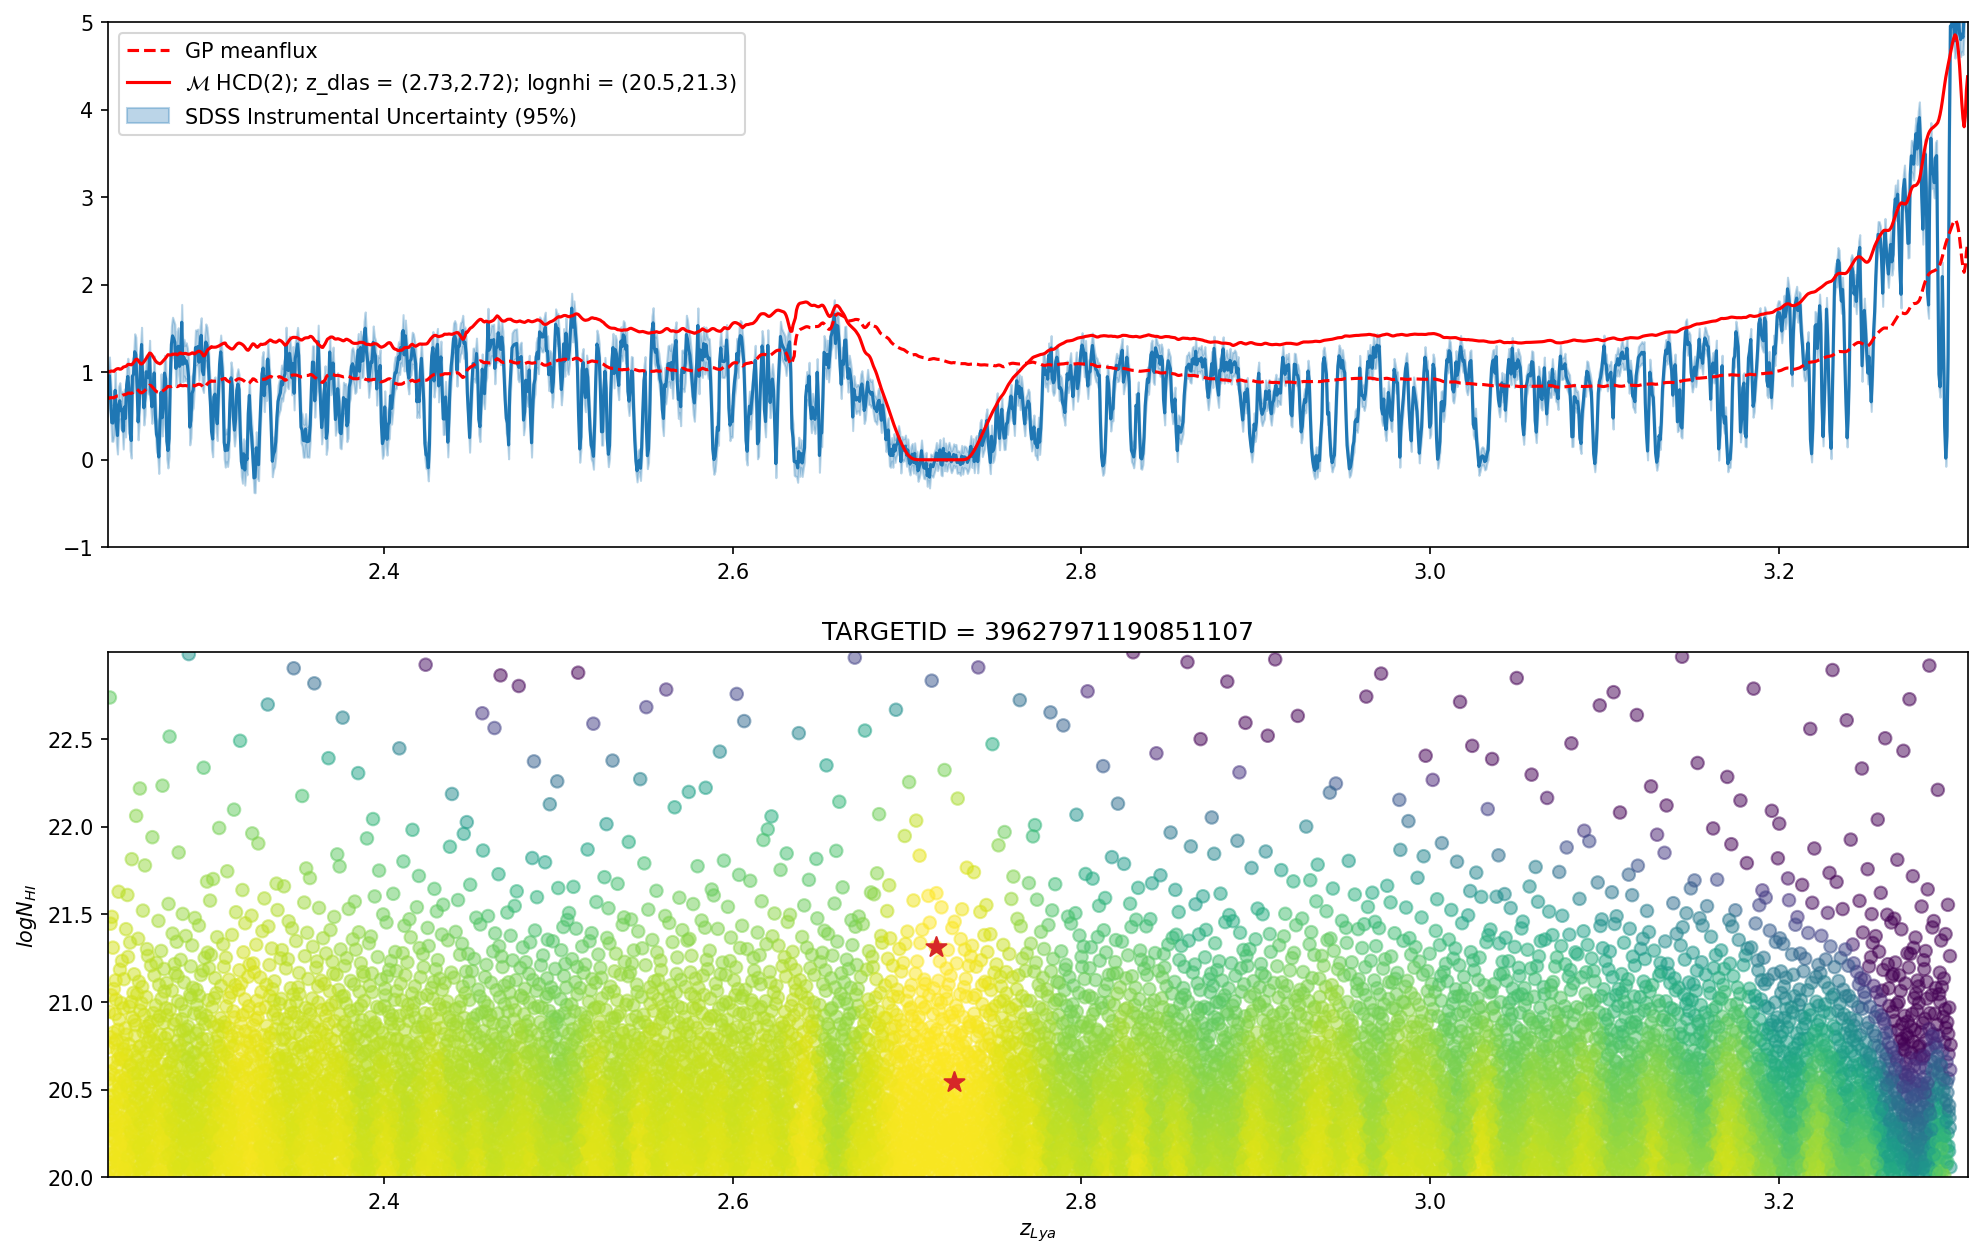

In [102]:
fig, ax, nth_lya, map_z_dlas, map_log_nhis, this_rest_wavelengths, lya_mu = processor.plot_results(z_qso, return_variables=True)
plt.title("TARGETID = " + str(tid))
# plt.close()
# plt.clf()

DESI Model:
p(Null) =  2.1066179713008088e-133
p(SubDLA/Alternative) =  5.121823055119719e-106
p(DLA+) =  [1.66985265e-02 9.83301194e-01 2.79937777e-07]
eBOSS Model:
p(Null) =  6.191298254814709e-108
p(SubDLA/Alternative) =  1.4120309556580744e-89
p(DLA+) =  [2.01508689e-04 9.99574000e-01 2.24491322e-04]


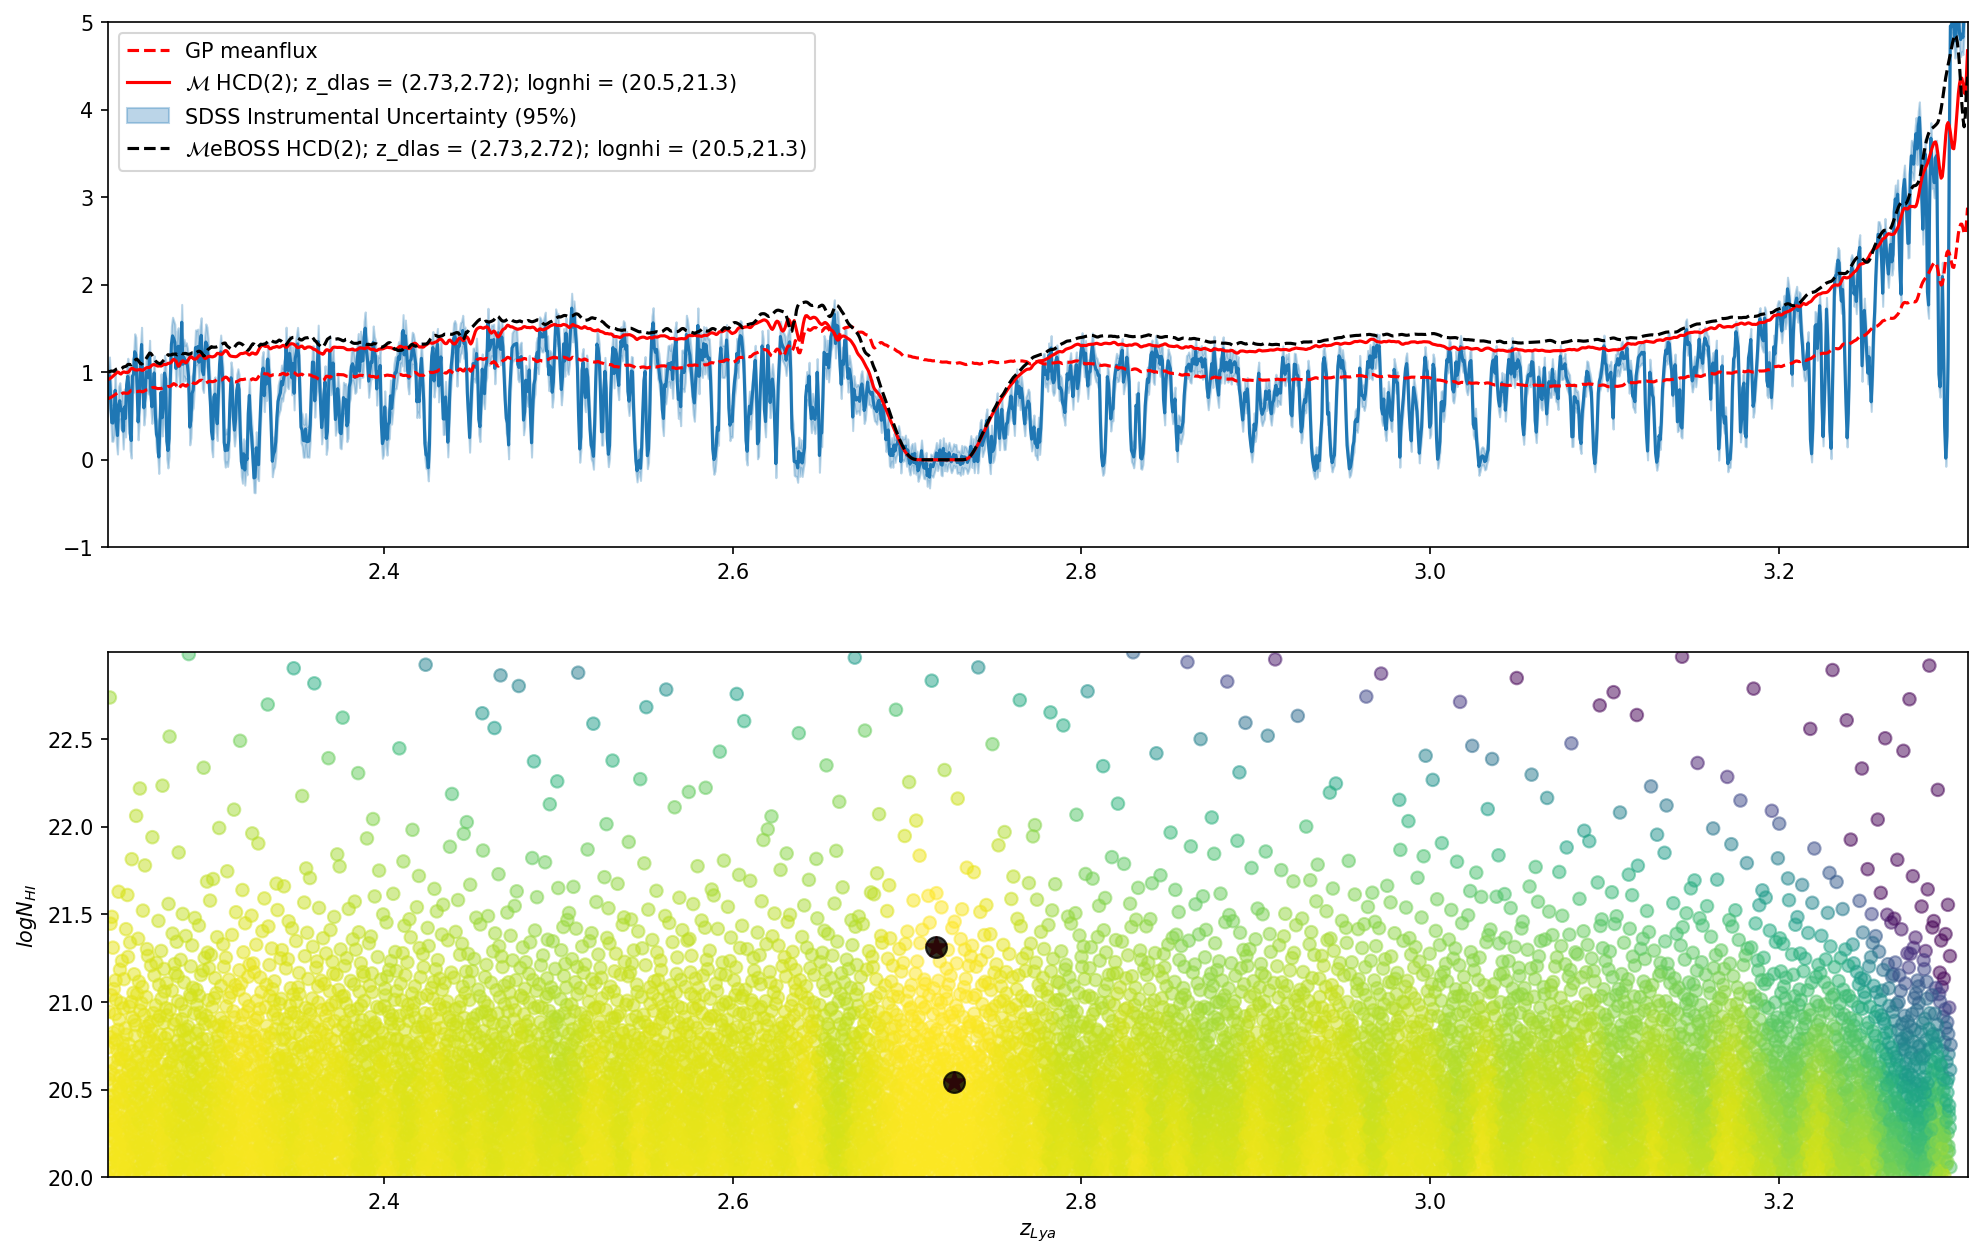

In [103]:
_fig, _ax = processor_desi.plot_results(z_qso,)
# MAP estimate
_ax[1].scatter(
    map_z_dlas, map_log_nhis,
    marker="o",
    s=100,
    color="black",
    alpha=0.8,
)
_ax[0].plot(
    (this_rest_wavelengths * (1 + z_qso)) / processor.dla_gp.params.lya_wavelength - 1,
    lya_mu,
    label=r"$\mathcal{M}$"
    + r"eBOSS HCD({n}); ".format(n=nth_lya)
    + "z_dlas = ({}); ".format(",".join("{:.3g}".format(z) for z in map_z_dlas))
    + "lognhi = ({})".format(
        ",".join("{:.3g}".format(n) for n in map_log_nhis)
    ),
    color="black",
    ls="--",
)
_ax[0].legend()

# Print results
print("DESI Model:")
print("p(Null) = ", results_desi["model_posteriors"][0, 0])
print("p(SubDLA/Alternative) = ", results_desi["model_posteriors"][0, 1])
print("p(DLA+) = ", results_desi["model_posteriors"][0, 2:])

# Print results
print("eBOSS Model:")
print("p(Null) = ", results["model_posteriors"][0, 0])
print("p(SubDLA/Alternative) = ", results["model_posteriors"][0, 1])
print("p(DLA+) = ", results["model_posteriors"][0, 2:])

plt.savefig("../learnlogs/comparison_eboss/plot_tid_{}.pdf".format(tid), format="pdf", dpi=150, )

## Comparison with others

In [104]:
from gpy_dla_detection.voigt import voigt_absorption



In [105]:
from astropy.table import Table
import numpy as np
mollycat = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_combined_cat_raw.fits"
# mollycat_gp = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_dla_cat_close_gp_bal_col.fits"
# mollycat_not_gp = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_dla_cat_not_gp_snr_15_bal_col_gt_910.fits"

mollycat = Table.read(mollycat)
# mollycat_gp = Table.read(mollycat_gp)
# mollycat_not_gp = Table.read(mollycat_not_gp)

In [106]:
ind = mollycat["TARGETID"] == tid
# CNN results
z_dla_cnn = mollycat[ind]["Z_DLA_CNN"]
_ind_nan = ~np.isnan(z_dla_cnn.value.data)
z_dla_cnn = z_dla_cnn.value.data[_ind_nan]
nhi_cnn = mollycat[ind]["NHI_CNN"]
nhi_cnn = nhi_cnn.value.data[_ind_nan]
# TEMP results
z_dla_temp = mollycat[ind]["Z_DLA_TMP"]
_ind_nan = ~np.isnan(z_dla_temp.value.data)
z_dla_temp = z_dla_temp.value.data[_ind_nan]
nhi_temp = mollycat[ind]["NHI_TMP"]
nhi_temp = nhi_temp.value.data[_ind_nan]


In [111]:
def plot_added_finder(ax, lya_gp, map_z_dlas:np.ndarray, map_log_nhis:np.ndarray, num_lines=2, marker="x", label="CNN", color="C2"):
    # lya_mu, lya_M, lya_omega2 = lya_gp.this_dla_gp(map_z_dlas, 10 ** map_log_nhis)

    nth_lya = len(map_z_dlas)
    absorption = np.ones_like(lya_gp.X)
    for i in range(len(map_log_nhis)):
        absorption *= voigt_absorption(
            lya_gp.X * (lya_gp.z_qso + 1),
            10**map_log_nhis[i],
            map_z_dlas[i],
            broadening=False,
            num_lines=num_lines,
        )
    
    _this_mu = lya_gp.mu_interpolator(lya_gp.X)
    # replace the lya_mu with the mu without meanflux suppression
    lya_mu = _this_mu * absorption

    # Only plot the spectrum within the search range
    this_rest_wavelengths = lya_gp.x
    ind = (this_rest_wavelengths < lya_gp.params.lya_wavelength)
    
    this_rest_wavelengths = this_rest_wavelengths[ind]
    lya_mu = lya_mu[ind]
    # _this_mu = _this_mu[ind]
    
    ax[0].plot(
        (this_rest_wavelengths * (1 + z_qso)) / lya_gp.params.lya_wavelength - 1,
        lya_mu,
        label=label
        + r"({n}); ".format(n=nth_lya)
        + "z_dlas = ({}); ".format(",".join("{:.3g}".format(z) for z in map_z_dlas))
        + "lognhi = ({})".format(
            ",".join("{:.3g}".format(n) for n in map_log_nhis)
        ),
        color=color,
    )
    
    # 2. Posterior space
    # MAP estimate
    ax[1].scatter(
        map_z_dlas, map_log_nhis,
        marker=marker,
        s=100,
        color=color,
    )
    return ax

(2.1119255963328483, 3.3088253236949923)

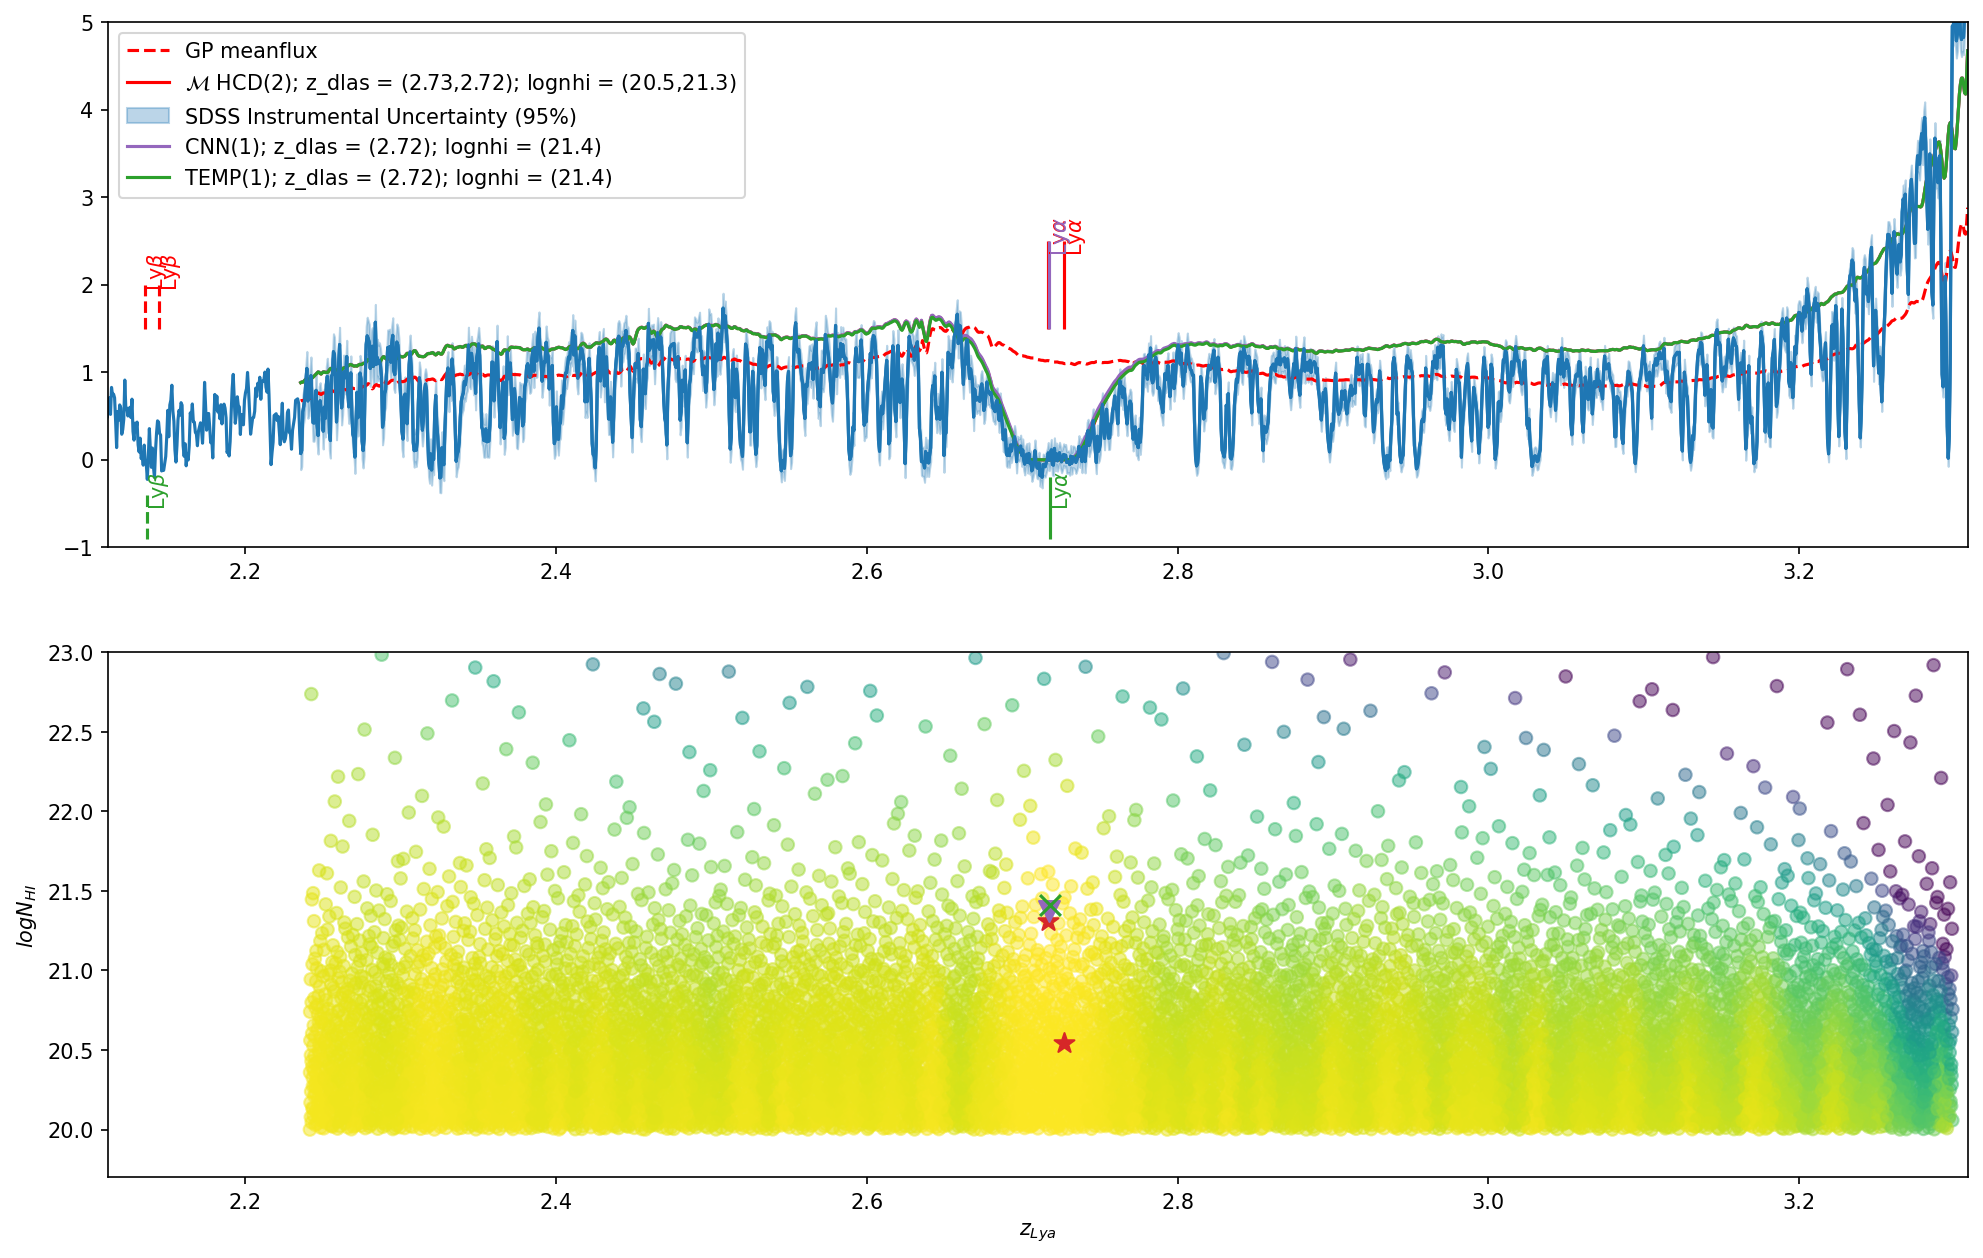

In [132]:
# z_dla_cnn = np.array([2.746385, 3.426490])
# nhi_cnn = np.array([19.805277, 21.702902])

# z_dla_temp = np.array([3.439142])
# nhi_temp = np.array([21.319272])


_fig, _ax = processor_desi.plot_results(z_qso,)

_ax = plot_added_finder(_ax, processor_desi.dla_gp, z_dla_cnn, nhi_cnn, num_lines=1, marker="v", color="C4")

_ax = plot_added_finder(_ax, processor_desi.dla_gp, z_dla_temp, nhi_temp, num_lines=2, marker="x", color="C2", label="TEMP")


###### GP ########
# Label the lya series lines
nth_lya = np.argmax(processor_desi.bayes.model_posteriors) - 1
MAP_z_dla, MAP_log_nhi = processor_desi.dla_gp.maximum_a_posteriori()
# make them to be 1-D array
map_z_dlas = MAP_z_dla[nth_lya - 1, :nth_lya]
map_log_nhis = MAP_log_nhi[nth_lya - 1, :nth_lya]

lambda_min = 850

## Lya
_ax[0].vlines(map_z_dlas, 1.5, 2.5, color="red", )
for z in map_z_dlas:
    _ax[0].text(z, 2.4, r"Ly$\alpha$", rotation=90, color="red")

## Lyb
map_z_dlbs = (map_z_dlas  + 1)*  1025.7 / 1215.67 - 1
ind = map_z_dlbs > lambda_min * (1 + z_qso) / 1216 - 1 
_ax[0].vlines(map_z_dlbs[ind], 1.5, 2, ls="--", color="red", )
for z in map_z_dlbs[ind]:
    _ax[0].text(z, 2, r"Ly$\beta$", rotation=90, color="red")

## Lyg
map_z_dlgs = (map_z_dlas  + 1)*  972.5 / 1215.67 - 1
ind = map_z_dlgs > lambda_min * (1 + z_qso) / 1216 - 1 
_ax[0].vlines(map_z_dlgs[ind], 1.5, 1.7, ls="dotted", color="red", )
for z in map_z_dlgs[ind]:
    _ax[0].text(z, 1.7, r"Ly$\gamma$", rotation=90, color="red")

###### CNN ########
## Lya
_ax[0].vlines(z_dla_cnn, 1.5, 2.5, color="C4", )
for z in z_dla_cnn:
    _ax[0].text(z, 2.4, r"Ly$\alpha$", rotation=90, color="C4")


###### TEMP #######
## Lya
_ax[0].vlines(z_dla_temp, -0.2, -0.9, color="C2", )
for z in z_dla_temp:
    _ax[0].text(z, -0.5, r"Ly$\alpha$", rotation=90, color="C2")

## Lyb
z_dlb_temp = (z_dla_temp  + 1)*  1025.7 / 1215.67 - 1
ind = z_dlb_temp > lambda_min * (1 + z_qso) / 1216 - 1 
_ax[0].vlines(z_dlb_temp[ind], -0.4, -0.9, ls="--", color="C2", )
for z in z_dlb_temp[ind]:
    _ax[0].text(z, -0.5, r"Ly$\beta$", rotation=90, color="C2")


_ax[0].legend()
_ax[1].set_ylim(19.7,23)

ind = (rest_wavelengths > processor_desi.dla_gp.params.normalization_min_lambda) & (rest_wavelengths < processor_desi.dla_gp.params.normalization_max_lambda)
median = np.median(flux[ind])
_ax[0].plot(rest_wavelengths * (1 + z_qso) / processor_desi.dla_gp.params.lya_wavelength - 1, flux / median, color="C0")

_ax[0].set_xlim(850 * (1 + z_qso) / 1216 - 1 + 0.1, z_qso)
_ax[1].set_xlim(850 * (1 + z_qso) / 1216 - 1 + 0.1, z_qso)

## Profiling

In [175]:
%%prun
process_single_spectrum(
    idx=0,
    spectrum_id=spectrum_id,
    z_qso=z_qso,
    wavelengths=wavelengths,
    rest_wavelengths=rest_wavelengths,
    flux=flux,
    noise_variance=noise_variance,
    pixel_mask=pixel_mask,
    params=params,
    prior=prior,
    dla_samples=dla_samples,
    subdla_samples=subdla_samples,
    bayes=bayes,
    results=results,
    max_dlas=max_dlas,  # Use the dynamic max_dlas
    broadening=True,
    gp=null_gp,  # Pass the pre-created NullGPMAT object
    dla_gp=dla_gp,  # Pass the pre-created DLAGPMAT object
    subdla_gp=subdla_gp,  # Pass the pre-created SubDLAGPMAT object
    min_z_separation=min_z_separation,
    plot_figures=False,
    max_workers=32,  # Parallel processing with 4 workers
    batch_size=313,
)

NameError: name 'spectrum_id' is not defined

In [43]:
from astropy.table import Table
import numpy as np
mollycat = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_combined_cat_raw.fits"
mollycat_gp = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_dla_cat_close_gp_bal_col.fits"
mollycat_not_gp = "/global/cfs/cdirs/desi/users/mwolfson/DLA_cat/loa_dla_cat_not_gp_snr_15_bal_col_gt_910.fits"

mollycat = Table.read(mollycat)
mollycat_gp = Table.read(mollycat_gp)
mollycat_not_gp = Table.read(mollycat_not_gp)

In [8]:
snr = mollycat_gp["SNR_REDSIDE"]
bal_mask = mollycat_gp["AI_CIV"]
ind = snr > 15
ind = ind & (bal_mask == 0)
ind = ind & (mollycat_gp["NHI"] > 20.3)

target_ids = np.unique(mollycat_gp[ind]["TARGETID"])
mollycat_gp[ind]

TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE,DLAID,Z_DLA,Z_DLA_ERR,NHI,NHI_ERR,DLAFLAG,P_DLA,P_NULL,LOGP_DLA,LOGP_NULL,MODEL_P,BALMASK,AI_CIV
int64,float64,float64,float64,float64,float64,bytes20,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,uint8,float32
39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428,39628061649405846000,2.1977228182792925,0.0450266239063178,20.42894113958262,0.09849866930169271,0,1.0000000000000224,-2.2426505097428162e-14,-706.3782857165957,-796.2586052587516,4.384703244527975e-30,0,0.0
39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428,39628061649405846002,2.2435212559117645,0.0010096600592108876,20.527798223149947,0.05601633496466793,0,1.0000000000000224,-2.2426505097428162e-14,-638.7788550084455,-796.2586052587516,0.999999866726748,0,0.0
39628180583088784,138.34296100622728,16.521147090002913,3.6905877559018476,26.597363042426263,45.63985253763381,39628180583088784000,2.738050086531855,0.018430607361970056,20.378098852029524,0.49690089436893575,0,1.0000000000000024,-2.4424906541753444e-15,-1028.382921781873,-1326.040602068634,0.000175097527222692,0,0.0
39628180583088784,138.34296100622728,16.521147090002913,3.6905877559018476,26.597363042426263,45.63985253763381,39628180583088784001,2.7493058649646245,1.011421159092385e-05,21.33203207037653,0.0001710437760358559,0,1.0000000000000024,-2.4424906541753444e-15,-1019.733030212181,-1326.040602068634,0.9997241668824148,0,0.0
39628283704250061,139.5569916617048,20.939933960294027,2.6972070394612793,10.748993588381765,18.397118362655252,39628283704250061000,2.42634044375786,0.007044274453591903,20.78890881085794,0.49700963220135463,0,0.9999999999999828,1.7208456881689926e-14,-439.08473590141426,-983.4984808234944,1.3735319670566053e-08,0,0.0
39628283704250061,139.5569916617048,20.939933960294027,2.6972070394612793,10.748993588381765,18.397118362655252,39628283704250061001,2.4161063091743396,0.0003539147173828401,21.50076452324476,0.005701267919109427,0,0.9999999999999828,1.7208456881689926e-14,-420.982389432344,-983.4984808234944,0.9990516755028341,0,0.0
39628086634876420,121.35638195400061,12.577417668586163,3.422108254853163,15.866938380082305,25.392455385100575,39628086634876420000,2.9929243731262902,0.0027163367097176624,20.512766993055124,0.4917193625566533,0,1.0000000000000724,-7.238654120556021e-14,-1052.5868646900776,-1585.0766365549944,1.8904077928106948e-12,0,0.0
39628086634876420,121.35638195400061,12.577417668586163,3.422108254853163,15.866938380082305,25.392455385100575,39628086634876420001,2.9818602744805744,0.0016534343452562343,21.618239685152616,0.03907548693095252,0,1.0000000000000724,-7.238654120556021e-14,-1025.5926361433408,-1585.0766365549944,0.999999999998181,0,0.0
39632940287656125,150.85469318752413,32.885269779655886,2.5154105876669965,8.666319859995232,15.749101733895596,39632940287656125000,2.345807756223986,0.005590106273370075,20.327986414133875,0.4844874331465333,0,1.0000000000000258,-2.5757174171303632e-14,-395.53677306142765,-709.3182728530018,0.42100381874661197,0,0.0


In [10]:
mollycat[np.where(mollycat["TARGETID"] == 39628061649405846)]

Z_DLA_CNN,NHI_CNN,NHI_STD_CNN,DLA_CONFIDENCE,Z_DLA_GP,Z_DLA_ERR_GP,NHI_GP,NHI_ERR_GP,P_DLA,LOGP_DLA,DLAFLAG_GP,Z_DLA_TMP,Z_DLA_ERR_TMP,NHI_TMP,NHI_ERR_TMP,DELTACHI2,DLAFLAG_TMP,Z_DLA,NHI,DLAID,TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes21,int64,float64,float64,float64,float64,float64
2.244477253903628,19.883209228515625,0.3318146765232086,0.8625,2.2435212559117645,0.0010096600592108876,20.527798223149947,0.05601633496466793,1.0000000000000224,-638.7788550084455,0.0,2.2431144356450727,0.02822229035747081,20.200000000000003,inf,0.07030782896630683,32.0,2.2435212559117645,20.527798223149947,39628061649405846003,39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428
2.7190946469639257,20.004165649414062,0.11946795135736465,0.9124999999999999,2.7202066609364093,0.00024233327556495043,20.295048417789854,0.03502925888851157,1.0000000000000224,-654.6097189970176,0.0,--,--,--,--,--,--,2.7202066609364093,20.295048417789854,39628061649405846004,39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428
3.249170091024406,20.10074806213379,0.11758716404438019,0.875,--,--,--,--,--,--,--,3.248335397561416,0.0038071910987822646,20.550000000000008,inf,1.3446801503821204,32.0,3.248335397561416,20.550000000000008,39628061649405846005,39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428
--,--,--,--,2.1977228182792925,0.0450266239063178,20.42894113958262,0.09849866930169271,1.0000000000000224,-706.3782857165957,0.0,--,--,--,--,--,--,2.1977228182792925,20.42894113958262,39628061649405846002,39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428
--,--,--,--,--,--,--,--,--,--,--,2.1713449994449414,0.055110705370163875,21.566040127703538,1.3873084455790003,0.3194830140874112,0.0,2.1713449994449414,21.566040127703538,39628061649405846001,39628061649405846,40.63109741114896,11.561496009711082,3.2488808899800983,12.92447003996443,22.144288256047428


Not GP

In [44]:
snr = mollycat_not_gp["SNR_REDSIDE"]
bal_mask = mollycat_not_gp["AI_CIV"]
ind = snr > 15
ind = ind & (bal_mask == 0)
ind = ind & (mollycat_not_gp["NHI"] > 20.3)

target_ids = np.unique(mollycat_not_gp[ind]["TARGETID"])
mollycat_not_gp[ind]

Z_DLA_CNN,NHI_CNN,NHI_STD_CNN,DLA_CONFIDENCE,Z_DLA_GP,Z_DLA_ERR_GP,NHI_GP,NHI_ERR_GP,P_DLA,LOGP_DLA,DLAFLAG_GP,Z_DLA_TMP,Z_DLA_ERR_TMP,NHI_TMP,NHI_ERR_TMP,DELTACHI2,DLAFLAG_TMP,Z_DLA,NHI,DLAID,TARGETID,RA,DEC,Z_QSO,SNR_FOREST,SNR_REDSIDE,BALMASK,AI_CIV
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes21,int64,float64,float64,float64,float64,float64,uint8,float32
--,--,--,--,--,--,--,--,--,--,--,3.872070234441262,0.005778680122409803,20.343368920801367,0.5948357753302762,2.221881178007358,0.0,3.872070234441262,20.343368920801367,39627392225903340007,39627392225903340,54.72287073621132,-16.450676155175685,4.0819022769984326,16.324553720793926,32.97275713692368,0,0.0
--,--,--,--,--,--,--,--,--,--,--,3.8060231804914166,0.004055127174590722,21.285092242420887,0.2523225275425521,9.783308381952338,0.0,3.8060231804914166,21.285092242420887,39627473415048710005,39627473415048710,15.82531275128093,-13.086162963290725,4.073432896765382,28.416702681479933,52.23287035857938,0,0.0
2.2566024657802295,20.619646072387695,0.13140073418617249,0.6875,--,--,--,--,--,--,--,2.2579342927792974,0.01888399459619542,--,inf,0.24832748796237025,32.0,2.2579342927792974,20.500000000000007,39627509095990433002,39627509095990433,30.625004683117353,-11.479408402723209,2.8531955831352347,12.36096790763745,17.459676192970754,0,0.0
--,--,--,--,--,--,--,--,--,--,--,2.2544435658168784,0.024628510443327683,20.526649530111335,2.0870942128893204,0.05057779971831078,0.0,2.2544435658168784,20.526649530111335,39627509095990433001,39627509095990433,30.625004683117353,-11.479408402723209,2.8531955831352347,12.36096790763745,17.459676192970754,0,0.0
2.060608086654247,--,0.2661207318305969,0.27499999999999997,--,--,--,--,--,--,--,2.0590180251103187,0.10826458660455913,20.66194368929566,4.883393985560399,0.0358440675613978,0.0,2.0590180251103187,20.66194368929566,39627586963243643001,39627586963243643,58.85166431461923,-8.138430424397164,3.0804698965911697,9.820318961732092,15.956811221802578,0,0.0
1.9728405450333173,--,0.3683576285839081,0.32499999999999996,--,--,--,--,--,--,--,1.9711398729986427,0.018928162327180573,21.113076437169596,0.9200682594770017,0.7217127054548786,0.0,1.9711398729986427,21.113076437169596,39627598082344549001,39627598082344549,7.633646126797639,-7.699006675430393,2.505831344445454,15.14614148907472,25.069945126618332,0,0.0
3.4264897688519262,21.70290184020996,0.07047878205776215,0.8375,--,--,--,--,--,--,--,--,--,--,--,--,--,3.4264897688519262,21.70290184020996,39627604172474708005,39627604172474708,13.707260163702811,-7.443404982475317,3.6321890548908304,14.730605714166266,27.36909813385852,0,0.0
3.9698660807309922,21.328125,0.09803168475627899,0.9125,--,--,--,--,--,--,--,--,--,--,--,--,--,3.9698660807309922,21.328125,39627619150334506003,39627619150334506,192.70522731839947,-6.966281951215035,4.72992860573415,11.989606438876747,28.286545800644806,0,0.0
1.9697371489441697,--,0.1383247673511505,0.45,1.9704810533920742,0.0008455468280497623,--,0.13850750794908545,0.9514860197393475,-365.97470748453736,0.0,1.9696566690865138,0.013062237713758314,20.589389689883784,1.3801470592292933,0.4304061186426109,0.0,1.9704810533920742,20.474417515788428,39627621624971391001,39627621624971391,341.12296992395926,-6.89700287849677,2.4955863090164843,14.168813662212935,26.271951118436576,0,0.0
